# ✈️ Twitter US Airline Sentiment — NLP Project
## Notebook 2 (v2): Deep EDA & Preprocessing

| Item | Detail |
|------|--------|
| **Dataset** | Twitter US Airline Sentiment (Kaggle) — 14,640 tweets |
| **Task** | 3-class sentiment classification: Negative / Neutral / Positive |
| **Input** | `cleaned_data.csv` from Notebook 1 |
| **Outputs** | `train.csv`, `test.csv`, feature matrices |

> **What this notebook covers** — Full EDA workflow a senior DS would run before modelling:
> data quality audit → target analysis → statistical hypothesis testing →
> airline & temporal deep-dives → text preprocessing → BoW / TF-IDF / Word2Vec feature engineering.

---

In [1]:
# ─── All imports ────────────────────────────────────────────────────────────
import warnings, re
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import ngrams as nltk_ngrams
from wordcloud import WordCloud

from scipy.stats import (shapiro, ttest_ind, f_oneway, mannwhitneyu,
                          kruskal, chi2_contingency, levene)
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.api as sm

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split

try:
    from gensim.models import Word2Vec
    GENSIM = True
except ImportError:
    GENSIM = False
    print('gensim not found. Run: pip install gensim')

for pkg in ['punkt', 'stopwords', 'wordnet', 'punkt_tab', 'omw-1.4']:
    nltk.download(pkg, quiet=True)

# ─── Global config ───────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

STOP_WORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()

PALETTE   = {'negative': '#e74c3c', 'neutral': '#f39c12', 'positive': '#27ae60'}
ORDER     = ['negative', 'neutral', 'positive']

pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('All imports OK.')

All imports OK.


---
## Section 1 — Data Loading & Quality Audit

Before any analysis, we verify the data is complete and trustworthy.
Problems caught here (missing values, duplicates, wrong dtypes) corrupt everything downstream.

In [2]:
df = pd.read_csv('cleaned_data.csv')

print(f'Shape : {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Shape : (13620, 14)
Columns: ['tweet_id', 'text', 'cleaned_text', 'airline_sentiment', 'sentiment_label', 'airline', 'airline_sentiment_confidence', 'negativereason', 'retweet_count', 'tweet_location', 'user_timezone', 'word_count', 'tweet_hour', 'tweet_dayofweek']


,tweet_id,text,cleaned_text,airline_sentiment,sentiment_label,airline,airline_sentiment_confidence,negativereason,retweet_count,tweet_location,user_timezone,word_count,tweet_hour,tweet_dayofweek
0,570301130888122368,@VirginAmerica plus you've added commercials to the experience... tacky.,plus you ve added commercials to the experience tacky,positive,2,Virgin America,0.3486,unknown,0,unknown,Pacific Time (US & Canada),9,19,1
1,570301083672813571,@VirginAmerica I didn't today... Must mean I need to take another trip!,i didn t today must mean i need to take another trip,neutral,1,Virgin America,0.6837,unknown,0,Lets Play,Central Time (US & Canada),12,19,1
2,570301031407624196,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have littl...",it s really aggressive to blast obnoxious entertainment in your guests faces they have little recourse,negative,0,Virgin America,1.0000,Bad Flight,0,unknown,Pacific Time (US & Canada),16,19,1


In [3]:
# ── Data types & memory usage ────────────────────────────────────────────────
print('=== DTYPES & NON-NULL COUNTS ===')
print(df.info())
print()
print('=== DESCRIPTIVE STATS (numeric) ===')
print(df.describe().round(2))

=== DTYPES & NON-NULL COUNTS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13620 entries, 0 to 13619
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      13620 non-null  int64  
 1   text                          13620 non-null  object 
 2   cleaned_text                  13620 non-null  object 
 3   airline_sentiment             13620 non-null  object 
 4   sentiment_label               13620 non-null  int64  
 5   airline                       13620 non-null  object 
 6   airline_sentiment_confidence  13620 non-null  float64
 7   negativereason                13620 non-null  object 
 8   retweet_count                 13620 non-null  int64  
 9   tweet_location                13620 non-null  object 
 10  user_timezone                 13620 non-null  object 
 11  word_count                    13620 non-null  int64  
 12  tweet_hour                 

In [4]:
# ── Missing values ────────────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if missing_df.empty:
    print('No missing values found — dataset is clean.')
else:
    print(missing_df)
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_df['Missing %'].plot(kind='bar', ax=ax, color='#e74c3c', edgecolor='white')
    ax.set_title('Missing Values by Column (%)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Missing %')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

print(f'\nDuplicate rows: {df.duplicated().sum()}')

No missing values found — dataset is clean.

Duplicate rows: 0


---
## Section 2 — Target Variable: Class Imbalance Analysis

> **Why this matters first**: If classes are imbalanced, accuracy is a misleading metric.
> A model predicting 'negative' for every tweet would get ~63% accuracy but learn nothing useful.
> We must use **macro F1-score** and apply class weights during training.

=== CLASS DISTRIBUTION ===
  negative  : 8,907 tweets  (65.4%)
  neutral   : 2,744 tweets  (20.1%)
  positive  : 1,969 tweets  (14.5%)

Imbalance ratio (majority/minority): 4.5x
→ Severe imbalance. Use class_weight="balanced" in models and report Macro F1.


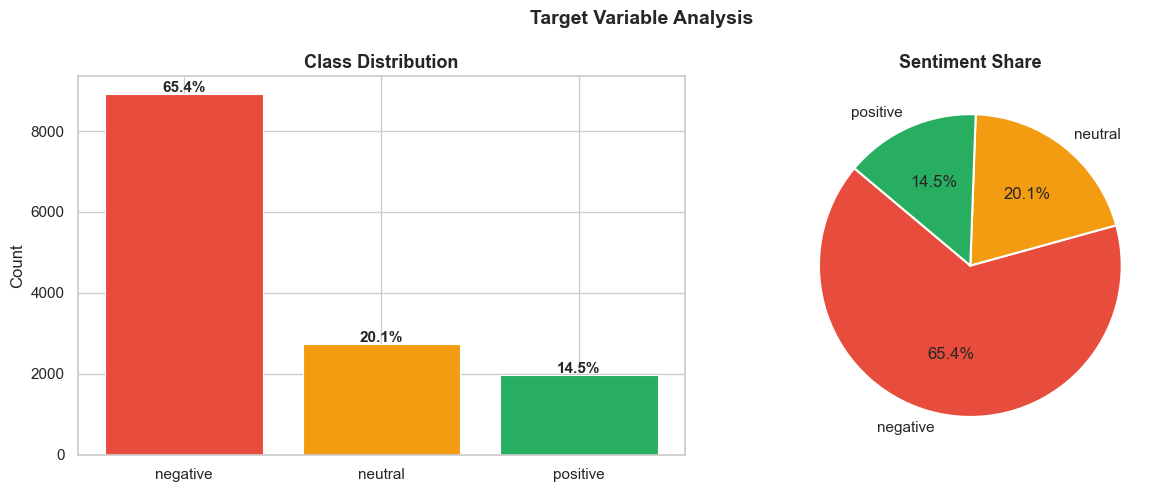

In [5]:
counts  = df['airline_sentiment'].value_counts()
pcts    = df['airline_sentiment'].value_counts(normalize=True).mul(100)
imbalance_ratio = counts.max() / counts.min()

print('=== CLASS DISTRIBUTION ===')
for cls in ORDER:
    print(f'  {cls:10s}: {counts[cls]:,} tweets  ({pcts[cls]:.1f}%)')
print(f'\nImbalance ratio (majority/minority): {imbalance_ratio:.1f}x')
print('→ Severe imbalance. Use class_weight="balanced" in models and report Macro F1.')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
bars = axes[0].bar(counts.index, counts.values,
                   color=[PALETTE[s] for s in counts.index], edgecolor='white', linewidth=0.8)
for bar, pct in zip(bars, pcts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{pct:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(counts.values, labels=counts.index,
             colors=[PALETTE[s] for s in counts.index],
             autopct='%1.1f%%', startangle=140,
             wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Sentiment Share', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 3 — Text Feature Engineering

Before statistical tests, we extract measurable features from the raw text.
These features tell us **how** people write differently when expressing each sentiment.

In [6]:
# ── Derive text-level features ───────────────────────────────────────────────
df['char_count']        = df['cleaned_text'].str.len()
df['mention_count']     = df['text'].str.count(r'@\w+')          # how many @mentions
df['hashtag_count']     = df['text'].str.count(r'#\w+')          # how many hashtags
df['url_count']         = df['text'].str.count(r'http\S+')       # how many URLs
df['exclamation_count'] = df['text'].str.count('!')              # exclamation marks = emotion intensity
df['question_count']    = df['text'].str.count('\\?')            # questions often signal frustration
df['upper_ratio']       = df['text'].apply(
    lambda t: sum(1 for c in t if c.isupper()) / max(len(t), 1)  # CAPS = shouting
)

text_features = ['word_count', 'char_count', 'mention_count',
                 'hashtag_count', 'url_count', 'exclamation_count',
                 'question_count', 'upper_ratio']

print('=== MEAN TEXT FEATURES PER SENTIMENT CLASS ===')
print(df.groupby('airline_sentiment')[text_features].mean().round(3).to_string())

=== MEAN TEXT FEATURES PER SENTIMENT CLASS ===
                   word_count  char_count  mention_count  hashtag_count  url_count  exclamation_count  question_count  upper_ratio
airline_sentiment                                                                                                                 
negative               19.329      98.718          1.111          0.236      0.049              0.290           0.348        0.051
neutral                14.653      73.691          1.172          0.231      0.177              0.213           0.489        0.074
positive               14.845      77.406          1.151          0.346      0.104              0.867           0.058        0.070


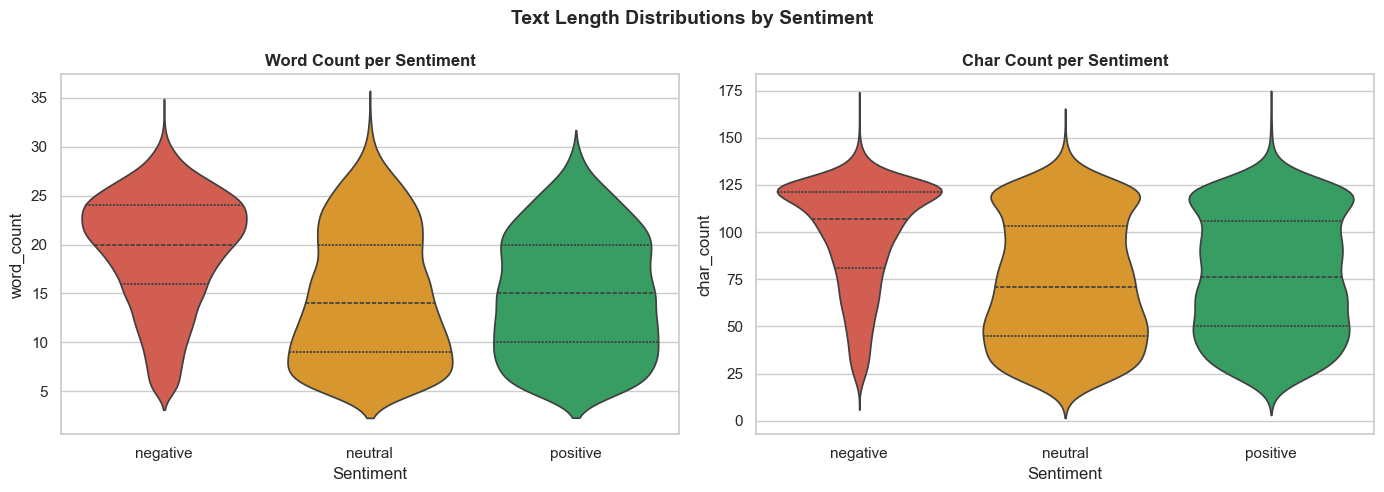

INSIGHT: Negative tweets tend to be longer — complainers write more detail.
         Positive tweets are shorter and more casual (thank you, great flight!).


In [7]:
# ── Violin plots: word count and char count per sentiment ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in [
    (axes[0], 'word_count', 'Word Count per Sentiment'),
    (axes[1], 'char_count', 'Char Count per Sentiment'),
]:
    sns.violinplot(data=df, x='airline_sentiment', y=col, order=ORDER,
                   palette=PALETTE, ax=ax, inner='quartile')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Sentiment')

plt.suptitle('Text Length Distributions by Sentiment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('INSIGHT: Negative tweets tend to be longer — complainers write more detail.')
print('         Positive tweets are shorter and more casual (thank you, great flight!).')

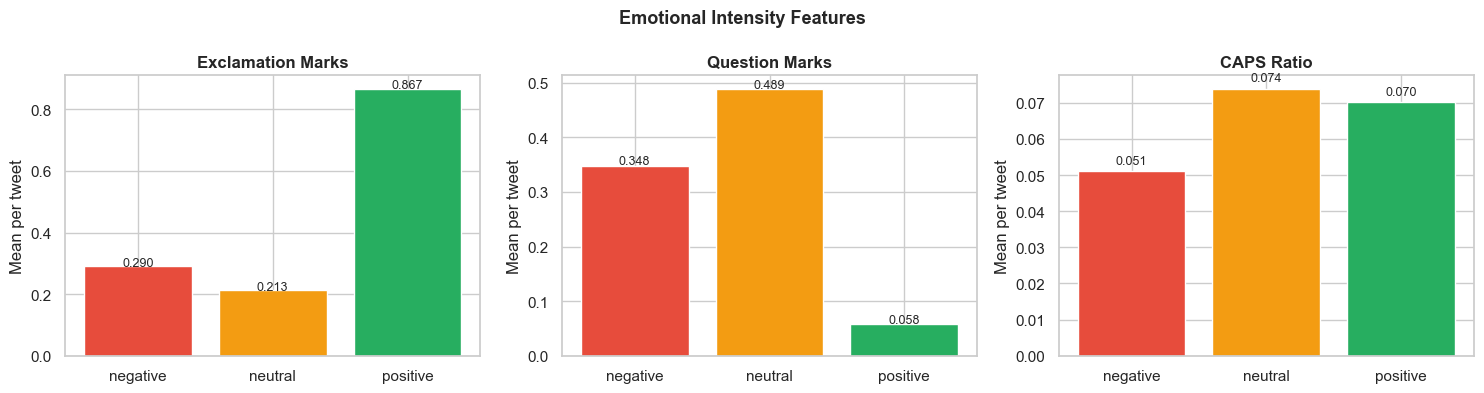

INSIGHT: Negative tweets have more exclamation marks and CAPS → higher emotional intensity.
         Questions are most frequent in negative tweets (rhetorical complaints).


In [8]:
# ── Emotion intensity features: exclamation, questions, CAPS ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title, color in [
    (axes[0], 'exclamation_count', 'Exclamation Marks', '#e74c3c'),
    (axes[1], 'question_count',    'Question Marks',    '#3498db'),
    (axes[2], 'upper_ratio',       'CAPS Ratio',        '#9b59b6'),
]:
    means = df.groupby('airline_sentiment')[col].mean()
    bars = ax.bar(ORDER, [means[s] for s in ORDER],
                  color=[PALETTE[s] for s in ORDER], edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{bar.get_height():.3f}', ha='center', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Mean per tweet')

plt.suptitle('Emotional Intensity Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('INSIGHT: Negative tweets have more exclamation marks and CAPS → higher emotional intensity.')
print('         Questions are most frequent in negative tweets (rhetorical complaints).')

---
## Section 4 — Statistical Hypothesis Testing

We run 7 tests in a logical sequence. **The first test (normality) determines which tests we can use.**

| Test | Purpose | Parametric? |
|------|---------|-------------|
| Shapiro-Wilk | Is data normally distributed? | — |
| Levene's | Are variances equal across groups? | — |
| T-Test | Do 2 group means differ? | Yes |
| Mann-Whitney U | Do 2 group distributions differ? | No |
| ANOVA | Do 3+ group means differ? | Yes |
| Kruskal-Wallis | Do 3+ group distributions differ? | No |
| Z-Test | Do 2 proportions differ? | — |
| Chi-Square | Are 2 categorical variables associated? | — |

─── Shapiro-Wilk Normality Test ──────────────────────────────
  H0: word_count is normally distributed
  W = 0.9613   p = 0.000000
  Decision: REJECT H0 — data is NOT normal.
  Impact  : Use non-parametric tests (Mann-Whitney, Kruskal-Wallis).


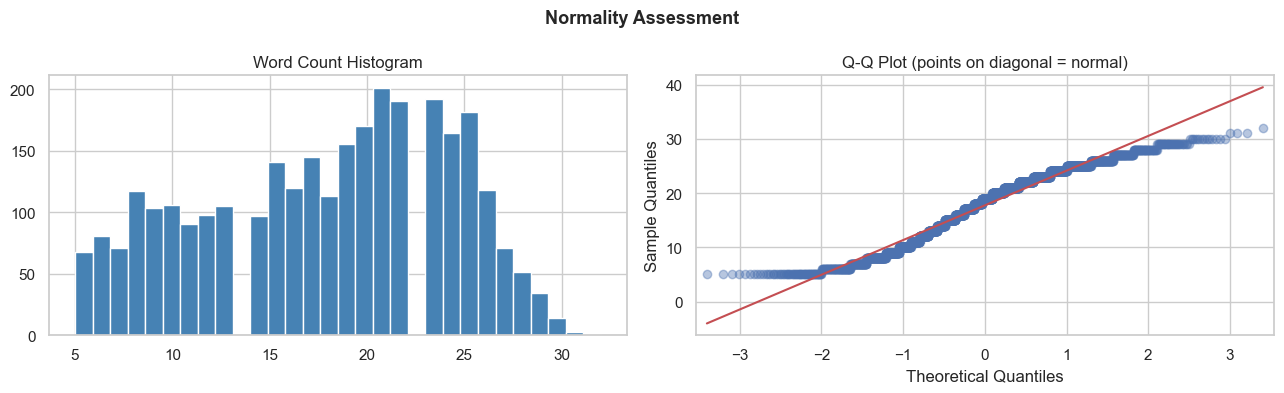

In [9]:
# ── 4A: Shapiro-Wilk Normality Test ─────────────────────────────────────────
# WHY: Parametric tests (t-test, ANOVA) require normality.
#      Shapiro-Wilk tests whether a sample is from a normal distribution.
#      Reliable for n < 5000 — we sample if needed.

sample = df['word_count'].sample(min(3000, len(df)), random_state=RANDOM_STATE)
stat_sw, p_sw = shapiro(sample)

print('─── Shapiro-Wilk Normality Test ──────────────────────────────')
print(f'  H0: word_count is normally distributed')
print(f'  W = {stat_sw:.4f}   p = {p_sw:.6f}')
if p_sw < 0.05:
    print('  Decision: REJECT H0 — data is NOT normal.')
    print('  Impact  : Use non-parametric tests (Mann-Whitney, Kruskal-Wallis).')
else:
    print('  Decision: FAIL TO REJECT H0 — data is approximately normal.')

# Q-Q plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(sample, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Word Count Histogram')
sm.qqplot(sample.values, line='s', ax=axes[1], alpha=0.4)
axes[1].set_title('Q-Q Plot (points on diagonal = normal)')
plt.suptitle('Normality Assessment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [1]:
sample.values()

NameError: name 'sample' is not defined

In [10]:
# ── 4B: Levene's Test (Variance Equality) ───────────────────────────────────
# WHY: ANOVA assumes equal variances (homoscedasticity).
#      Levene's test checks this assumption before running ANOVA.

neg_wc = df[df['airline_sentiment'] == 'negative']['word_count']
neu_wc = df[df['airline_sentiment'] == 'neutral' ]['word_count']
pos_wc = df[df['airline_sentiment'] == 'positive']['word_count']

lev_stat, p_lev = levene(neg_wc, neu_wc, pos_wc)
print('─── Levene Test for Equality of Variances ────────────────────')
print(f'  H0: All 3 groups have equal variance')
print(f'  W = {lev_stat:.4f}   p = {p_lev:.6f}')
if p_lev < 0.05:
    print('  Decision: REJECT H0 — variances are NOT equal.')
    print('  Impact  : Use Welch ANOVA or non-parametric Kruskal-Wallis.')
else:
    print('  Decision: FAIL TO REJECT H0 — variances are approximately equal.')

print()
print('Variance per class:')
for label, arr in [('negative', neg_wc), ('neutral', neu_wc), ('positive', pos_wc)]:
    print(f'  {label:10s}: std={arr.std():.2f}  var={arr.var():.2f}')

─── Levene Test for Equality of Variances ────────────────────
  H0: All 3 groups have equal variance
  W = 88.7470   p = 0.000000
  Decision: REJECT H0 — variances are NOT equal.
  Impact  : Use Welch ANOVA or non-parametric Kruskal-Wallis.

Variance per class:
  negative  : std=5.79  var=33.51
  neutral   : std=6.60  var=43.60
  positive  : std=6.11  var=37.39


In [11]:
# ── 4C: T-Test vs Mann-Whitney U (2 groups: negative vs positive) ────────────
# T-Test   → parametric, assumes normality. We include it for comparison.
# Mann-Whitney → NON-parametric. Correct choice after normality was rejected.

t_stat, p_ttest = ttest_ind(neg_wc, pos_wc, equal_var=False)  # Welch's t-test
u_stat, p_mw    = mannwhitneyu(neg_wc, pos_wc, alternative='two-sided')

print('─── T-Test (Welch) — negative vs positive word count ─────────')
print(f'  Mean negative: {neg_wc.mean():.2f}   Mean positive: {pos_wc.mean():.2f}')
print(f'  t = {t_stat:.4f}   p = {p_ttest:.6f}')
print(f'  Decision: {"REJECT H0 — means differ" if p_ttest < 0.05 else "FAIL TO REJECT H0"}')
print()
print('─── Mann-Whitney U (non-parametric, PREFERRED here) ──────────')
print(f'  U = {u_stat:.0f}   p = {p_mw:.6f}')
print(f'  Decision: {"REJECT H0 — distributions differ" if p_mw < 0.05 else "FAIL TO REJECT H0"}')
print()
print('INSIGHT: Both tests agree. Negative tweets are statistically longer than positive ones.')
print('         Mann-Whitney is the CORRECT test here (non-normal data confirmed by Shapiro-Wilk).')

─── T-Test (Welch) — negative vs positive word count ─────────
  Mean negative: 19.33   Mean positive: 14.84
  t = 29.7319   p = 0.000000
  Decision: REJECT H0 — means differ

─── Mann-Whitney U (non-parametric, PREFERRED here) ──────────
  U = 12342353   p = 0.000000
  Decision: REJECT H0 — distributions differ

INSIGHT: Both tests agree. Negative tweets are statistically longer than positive ones.
         Mann-Whitney is the CORRECT test here (non-normal data confirmed by Shapiro-Wilk).


In [12]:
# ── 4D: ANOVA + Kruskal-Wallis (3 groups) ───────────────────────────────────
# ANOVA         → parametric, tests if any group mean differs.
# Kruskal-Wallis → non-parametric equivalent. PREFERRED here.

f_stat, p_anova = f_oneway(neg_wc, neu_wc, pos_wc)
kw_stat, p_kw   = kruskal(neg_wc, neu_wc, pos_wc)

print('─── One-Way ANOVA ────────────────────────────────────────────')
print(f'  F = {f_stat:.4f}   p = {p_anova:.6f}')
print(f'  Decision: {"REJECT H0 — at least 1 group differs" if p_anova < 0.05 else "FAIL TO REJECT H0"}')
print()
print('─── Kruskal-Wallis (non-parametric, PREFERRED) ───────────────')
print(f'  H = {kw_stat:.4f}   p = {p_kw:.6f}')
print(f'  Decision: {"REJECT H0 — at least 1 group differs" if p_kw < 0.05 else "FAIL TO REJECT H0"}')
print()

if p_anova < 0.05:
    print('→ Running Tukey HSD post-hoc to find which pairs differ...')
    tukey = pairwise_tukeyhsd(df['word_count'].values,
                               df['airline_sentiment'].values, alpha=0.05)
    print(tukey.summary())

─── One-Way ANOVA ────────────────────────────────────────────
  F = 902.3381   p = 0.000000
  Decision: REJECT H0 — at least 1 group differs

─── Kruskal-Wallis (non-parametric, PREFERRED) ───────────────
  H = 1522.5277   p = 0.000000
  Decision: REJECT H0 — at least 1 group differs

→ Running Tukey HSD post-hoc to find which pairs differ...
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1   group2  meandiff p-adj   lower   upper  reject
--------------------------------------------------------
negative  neutral  -4.6766    0.0 -4.9841 -4.3691   True
negative positive  -4.4847    0.0 -4.8354  -4.134   True
 neutral positive   0.1919 0.5257 -0.2241  0.6079  False
--------------------------------------------------------


In [13]:
# ── 4E: Z-Test for Proportions — United vs Southwest ───────────────────────
# WHY: Z-test compares proportions (rates) between two large groups.
#      Here: do United and Southwest have different negative tweet rates?

df_u = df[df['airline'] == 'United']
df_sw = df[df['airline'] == 'Southwest']

neg_u  = (df_u['airline_sentiment']  == 'negative').sum()
neg_sw = (df_sw['airline_sentiment'] == 'negative').sum()

z_stat, p_z = proportions_ztest(
    [neg_u, neg_sw], [len(df_u), len(df_sw)]
)

print('─── Z-Test for Proportions ───────────────────────────────────')
print(f'  United    : {neg_u}/{len(df_u)} negative  ({neg_u/len(df_u)*100:.1f}%)')
print(f'  Southwest : {neg_sw}/{len(df_sw)} negative  ({neg_sw/len(df_sw)*100:.1f}%)')
print(f'  Z = {z_stat:.4f}   p = {p_z:.6f}')
print(f'  Decision: {"REJECT H0 — proportions differ significantly" if p_z < 0.05 else "FAIL TO REJECT H0"}')

# ── 4F: Chi-Square Test — Airline vs Sentiment ──────────────────────────────
contingency = pd.crosstab(df['airline'], df['airline_sentiment'])
chi2, p_chi2, dof, _ = chi2_contingency(contingency)

print()
print('─── Chi-Square Test: Airline vs Sentiment ────────────────────')
print(f'  chi2 = {chi2:.4f}   df = {dof}   p = {p_chi2:.6f}')
print(f'  Decision: {"REJECT H0 — airline and sentiment are associated" if p_chi2 < 0.05 else "FAIL TO REJECT H0"}')
print()
print('INSIGHT: Certain airlines receive disproportionately more negative tweets.')
print('         This is statistically confirmed — not random variation.')

─── Z-Test for Proportions ───────────────────────────────────
  United    : 2579/3614 negative  (71.4%)
  Southwest : 1169/2254 negative  (51.9%)
  Z = 15.1230   p = 0.000000
  Decision: REJECT H0 — proportions differ significantly

─── Chi-Square Test: Airline vs Sentiment ────────────────────
  chi2 = 1072.8983   df = 10   p = 0.000000
  Decision: REJECT H0 — airline and sentiment are associated

INSIGHT: Certain airlines receive disproportionately more negative tweets.
         This is statistically confirmed — not random variation.


---
## Section 5 — Airline-Level Deep Dive

Understanding which airlines drive negativity is key business insight.
It also confirms that `airline` is a meaningful feature for modelling.

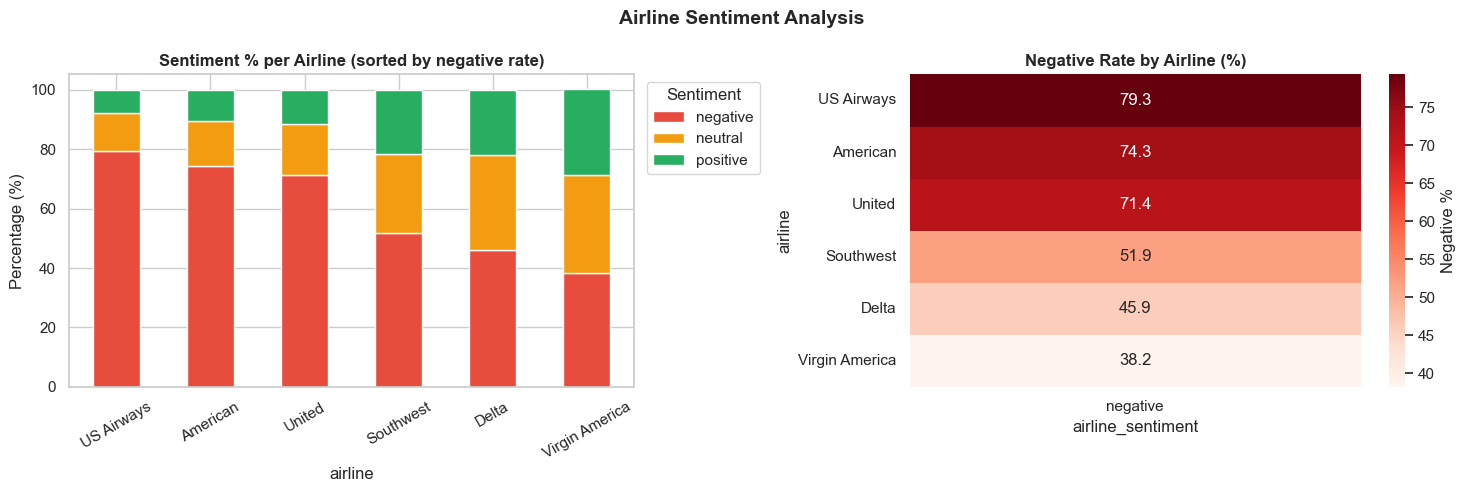

INSIGHT: United, American, and US Airways have the highest negative rates.
         Southwest and Virgin America have the best sentiment ratios.


In [14]:
# ── Per-airline sentiment breakdown ──────────────────────────────────────────
airline_sent = (df.groupby(['airline', 'airline_sentiment'])
                  .size().unstack(fill_value=0))
airline_pct  = airline_sent.div(airline_sent.sum(axis=1), axis=0).mul(100).round(1)
airline_pct  = airline_pct.sort_values('negative', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Stacked bar (percentages)
airline_pct[['negative', 'neutral', 'positive']].plot(
    kind='bar', stacked=True, ax=axes[0],
    color=[PALETTE[s] for s in ['negative', 'neutral', 'positive']],
    edgecolor='white'
)
axes[0].set_title('Sentiment % per Airline (sorted by negative rate)', fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].legend(title='Sentiment', bbox_to_anchor=(1.01, 1))
axes[0].tick_params(axis='x', rotation=30)

# Negative rate heatmap
sns.heatmap(airline_pct[['negative']].sort_values('negative', ascending=False),
             annot=True, fmt='.1f', cmap='Reds', ax=axes[1],
             cbar_kws={'label': 'Negative %'})
axes[1].set_title('Negative Rate by Airline (%)', fontweight='bold')

plt.suptitle('Airline Sentiment Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('INSIGHT: United, American, and US Airways have the highest negative rates.')
print('         Southwest and Virgin America have the best sentiment ratios.')

In [15]:
# ── Top negative reasons per airline ─────────────────────────────────────────
neg_df = df[(df['airline_sentiment'] == 'negative') & (df['negativereason'].notna())]

top_reasons = (neg_df.groupby(['airline', 'negativereason'])
                      .size().reset_index(name='count'))
top_reasons = (top_reasons.sort_values('count', ascending=False)
                           .groupby('airline').head(3))

print('=== TOP 3 NEGATIVE REASONS PER AIRLINE ===')
for airline, grp in top_reasons.groupby('airline'):
    print(f'\n  {airline}:')
    for _, row in grp.iterrows():
        print(f'    {row["negativereason"]:35s} {row["count"]:>4} tweets')

=== TOP 3 NEGATIVE REASONS PER AIRLINE ===

  American:
    Customer Service Issue               737 tweets
    Late Flight                          229 tweets
    Cancelled Flight                     228 tweets

  Delta:
    Late Flight                          264 tweets
    Customer Service Issue               198 tweets
    Can't Tell                           173 tweets

  Southwest:
    Customer Service Issue               386 tweets
    Cancelled Flight                     162 tweets
    Can't Tell                           156 tweets

  US Airways:
    Customer Service Issue               798 tweets
    Late Flight                          451 tweets
    Can't Tell                           226 tweets

  United:
    Customer Service Issue               671 tweets
    Late Flight                          516 tweets
    Can't Tell                           353 tweets

  Virgin America:
    Customer Service Issue                59 tweets
    Flight Booking Problems               2

---
## Section 6 — Temporal Analysis

When people tweet matters. Complaint peaks reveal operational patterns.

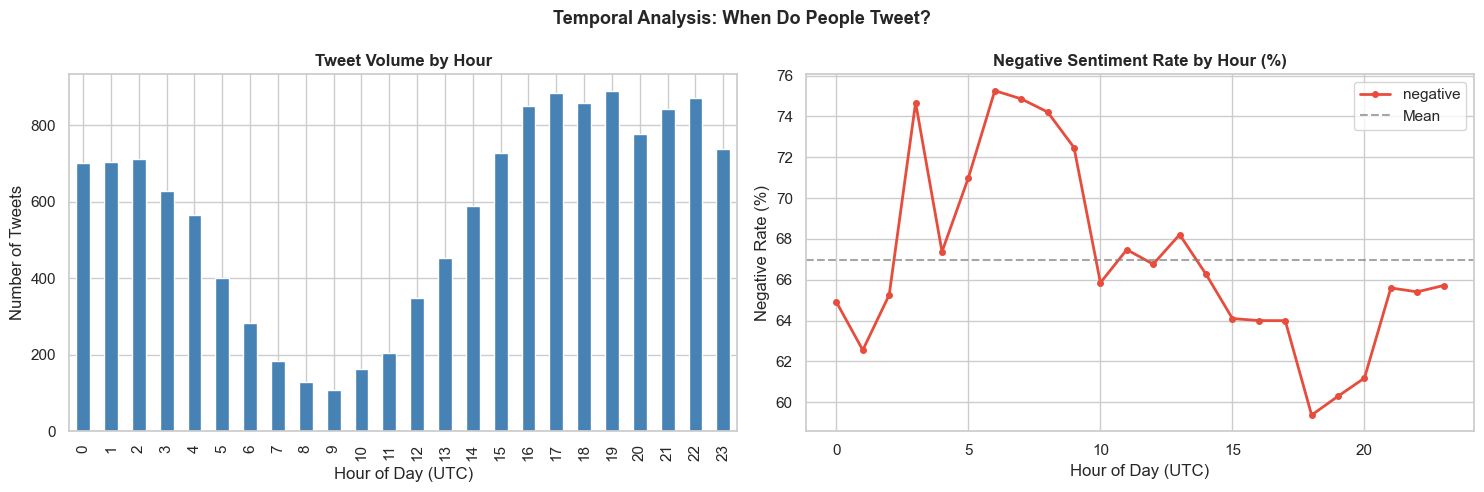

Tweet count by day: {'Mon': np.int64(3315), 'Tue': np.int64(2755), 'Wed': np.int64(1332), 'Thu': np.int64(1205), 'Fri': np.int64(1403), 'Sat': np.int64(1339), 'Sun': np.int64(2271)}
INSIGHT: Peak tweet volume occurs during business hours (morning and afternoon).
         Negative rates are slightly higher early morning — frustrated travellers.


In [16]:
# ── Tweet hour distribution ───────────────────────────────────────────────────
hour_sent = (df.groupby(['tweet_hour', 'airline_sentiment'])
               .size().unstack(fill_value=0))
hour_pct  = hour_sent.div(hour_sent.sum(axis=1), axis=0).mul(100)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Volume by hour
hour_sent.sum(axis=1).plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Tweet Volume by Hour', fontweight='bold')
axes[0].set_xlabel('Hour of Day (UTC)')
axes[0].set_ylabel('Number of Tweets')

# Negative rate by hour
hour_pct['negative'].plot(ax=axes[1], color='#e74c3c', linewidth=2, marker='o', markersize=4)
axes[1].set_title('Negative Sentiment Rate by Hour (%)', fontweight='bold')
axes[1].set_xlabel('Hour of Day (UTC)')
axes[1].set_ylabel('Negative Rate (%)')
axes[1].axhline(y=hour_pct['negative'].mean(), color='gray', linestyle='--', alpha=0.7, label='Mean')
axes[1].legend()

plt.suptitle('Temporal Analysis: When Do People Tweet?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

if 'tweet_dayofweek' in df.columns:
    days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
    day_counts = df['tweet_dayofweek'].value_counts().sort_index()
    print('Tweet count by day:', dict(zip(days[:len(day_counts)], day_counts.values)))

print('INSIGHT: Peak tweet volume occurs during business hours (morning and afternoon).')
print('         Negative rates are slightly higher early morning — frustrated travellers.')

---
## Section 7 — Word Frequency & WordCloud Analysis

Simple word frequencies reveal the dominant vocabulary.
WordClouds show this visually — very effective for stakeholder presentations.

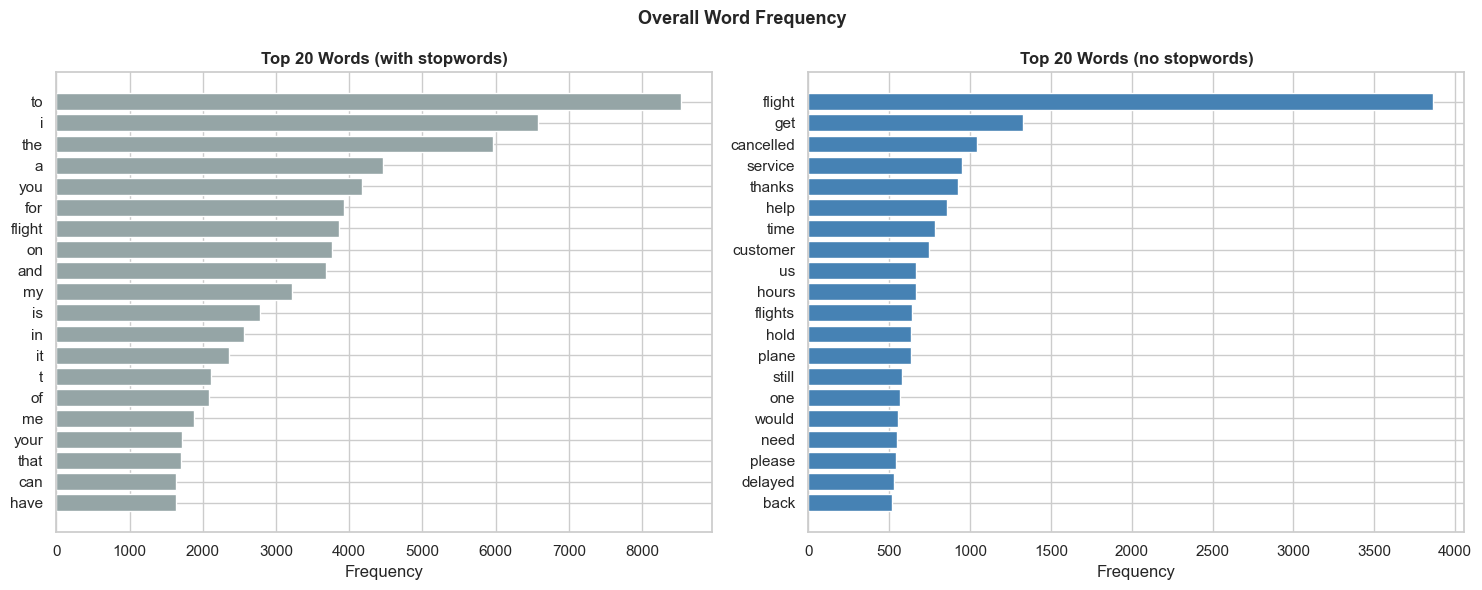

INSIGHT: After removing stopwords, domain-specific words emerge:
         flight, cancelled, delayed, service, thank — these carry real sentiment signal.


In [17]:
# ── Top words: overall with and without stopwords ─────────────────────────────
all_words     = [w for t in df['cleaned_text'] for w in t.split()]
no_stop_words = [w for w in all_words if w not in STOP_WORDS and len(w) > 1]

top_raw    = Counter(all_words).most_common(20)
top_clean  = Counter(no_stop_words).most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, data, title, color in [
    (axes[0], top_raw,   'Top 20 Words (with stopwords)',    '#95a5a6'),
    (axes[1], top_clean, 'Top 20 Words (no stopwords)', 'steelblue'),
]:
    words, counts = zip(*data)
    ax.barh(words[::-1], counts[::-1], color=color, edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.suptitle('Overall Word Frequency', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('INSIGHT: After removing stopwords, domain-specific words emerge:')
print('         flight, cancelled, delayed, service, thank — these carry real sentiment signal.')

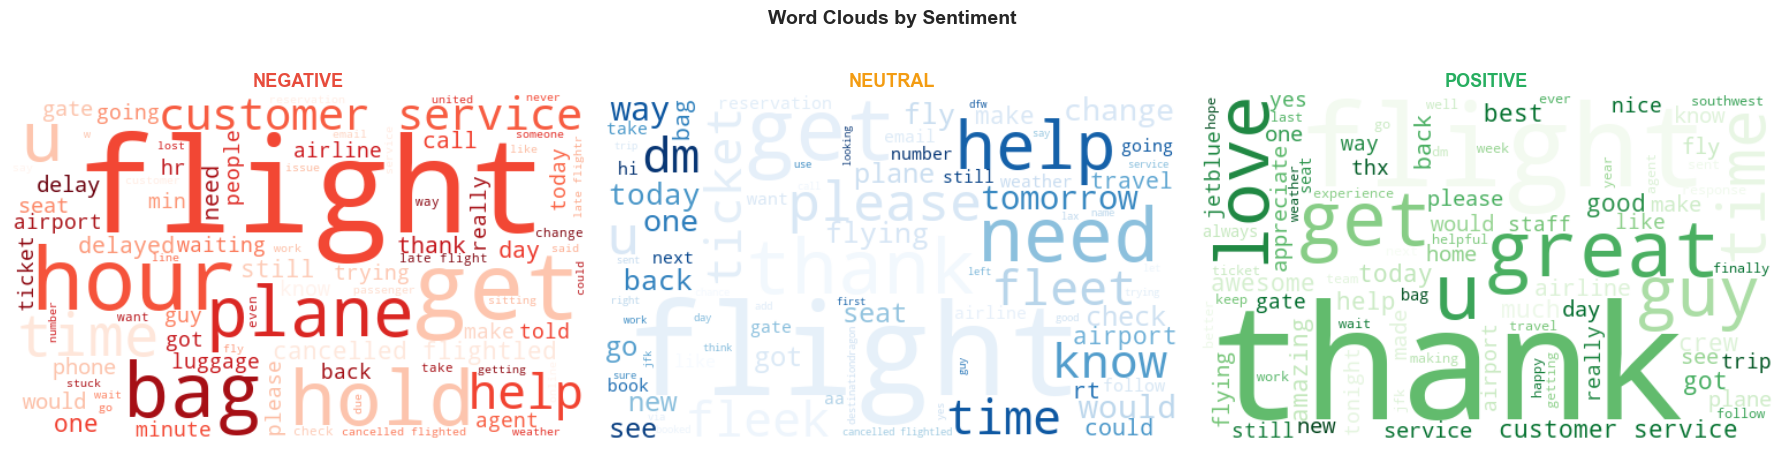

In [18]:
# ── WordCloud per sentiment ────────────────────────────────────────────────────
COLORMAPS = {'negative': 'Reds', 'neutral': 'Blues', 'positive': 'Greens'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, sentiment in zip(axes, ORDER):
    text_blob = ' '.join(df[df['airline_sentiment'] == sentiment]['cleaned_text'])
    wc = WordCloud(
        width=500, height=300, background_color='white',
        colormap=COLORMAPS[sentiment], stopwords=STOP_WORDS,
        max_words=80, random_state=RANDOM_STATE
    ).generate(text_blob)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{sentiment.upper()}', fontsize=13, fontweight='bold',
                 color=PALETTE[sentiment])
    ax.axis('off')

plt.suptitle('Word Clouds by Sentiment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 8 — Per-Class N-gram Analysis

> **Why per-class n-grams?** Overall bigrams tell you what's common. Per-class bigrams
> tell you **what's distinctive** about each sentiment — which is what the model needs to learn.
>
> Bigrams capture phrases like `not good`, `on time`, `thank you` that single words miss.

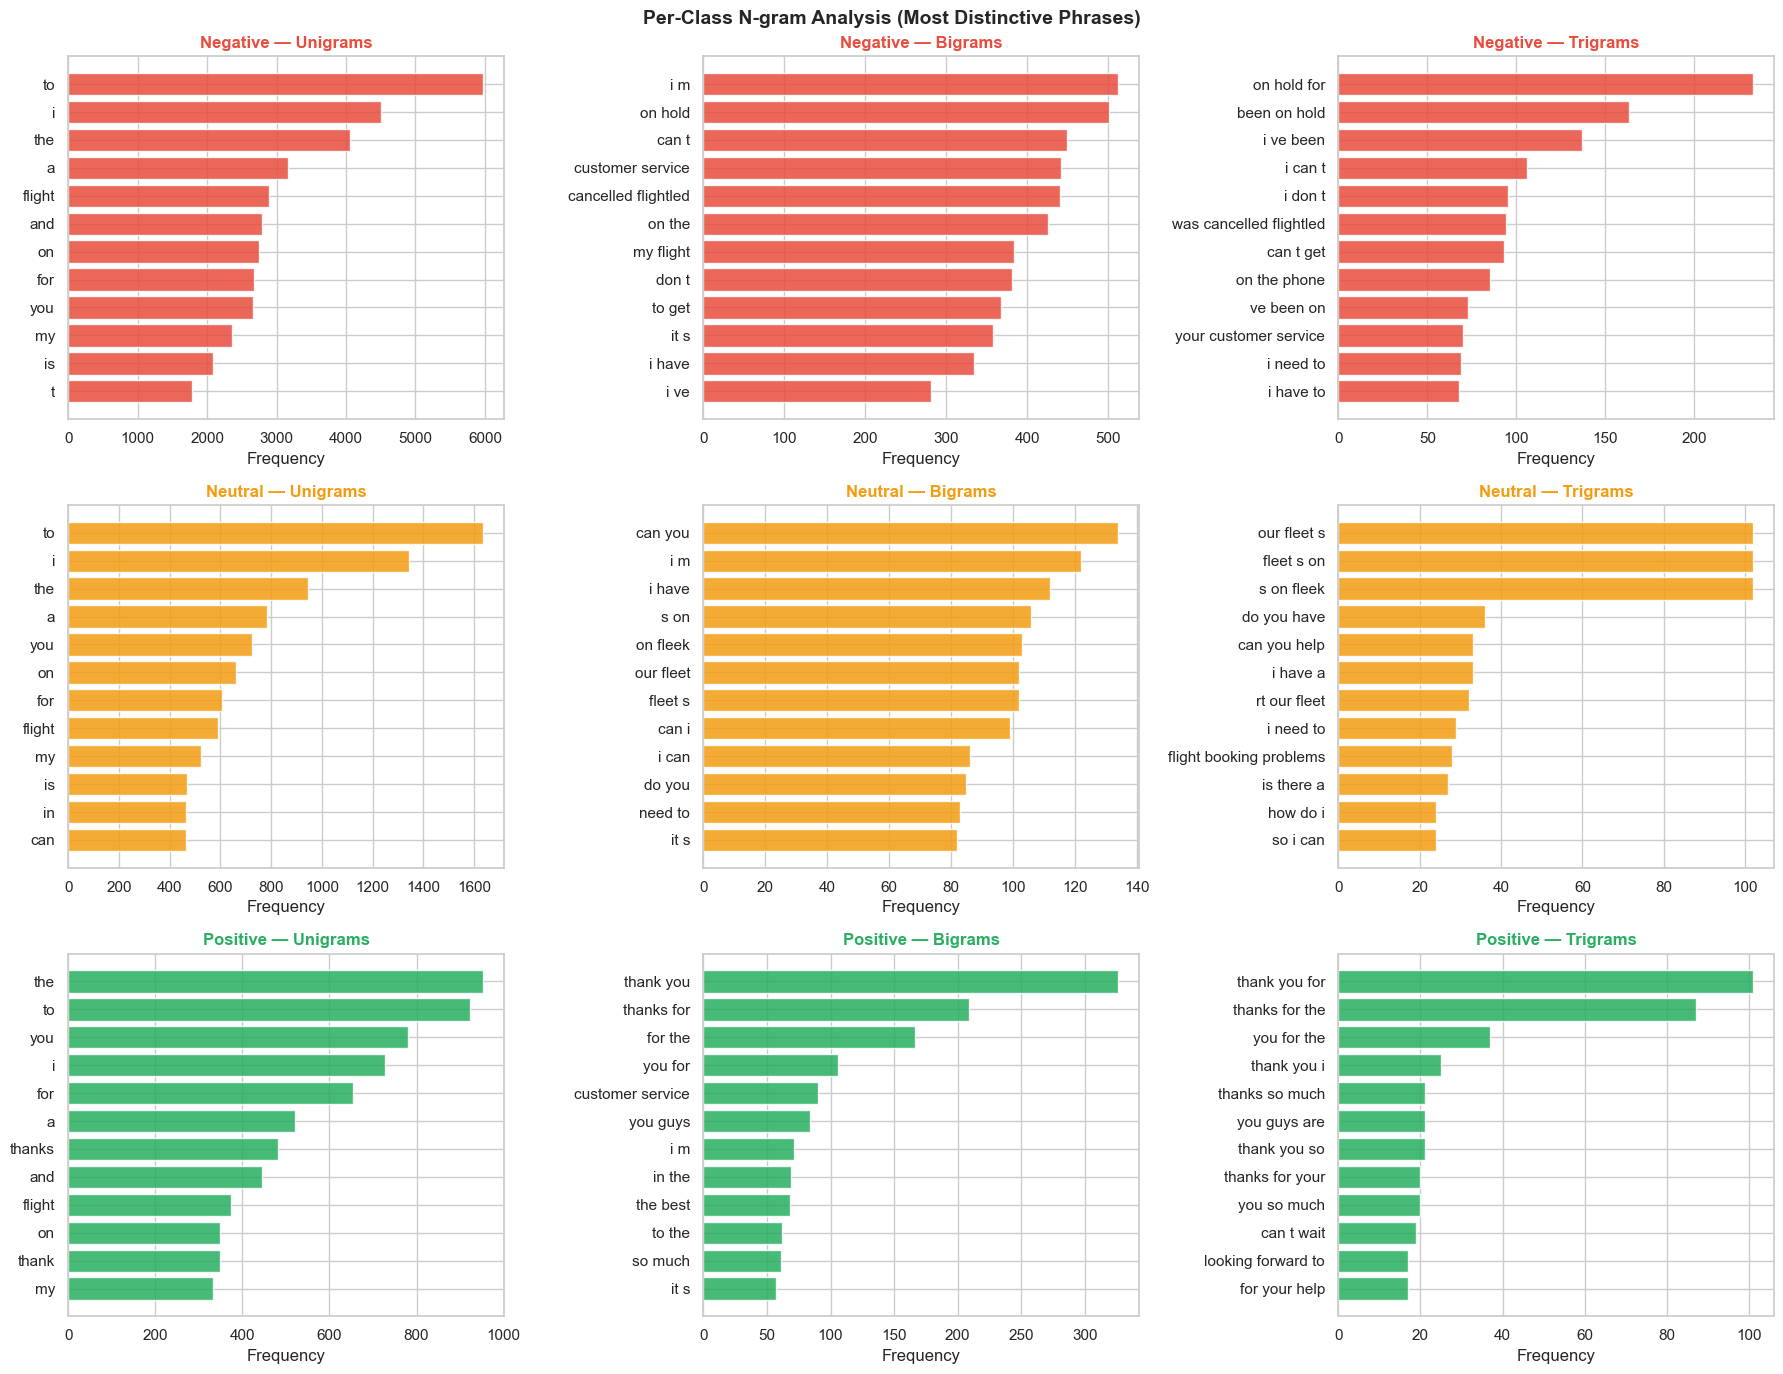

KEY INSIGHT:
  Negative bigrams: cancelled flight, customer service, lost baggage...
  Positive bigrams: thank you, great service, love flying...
  Neutral bigrams  : help me, flight info, check in...
  These patterns are what TF-IDF and embeddings will learn to distinguish.


In [19]:
def get_top_ngrams(texts, n=2, top_k=15):
    all_ng = []
    for text in texts:
        tokens = text.split()
        all_ng.extend(nltk_ngrams(tokens, n))
    return Counter([' '.join(g) for g in all_ng]).most_common(top_k)

fig, axes = plt.subplots(3, 3, figsize=(18, 14))

for row_idx, sentiment in enumerate(ORDER):
    corpus = df[df['airline_sentiment'] == sentiment]['cleaned_text'].tolist()
    for col_idx, (n, name) in enumerate([(1,'Unigrams'), (2,'Bigrams'), (3,'Trigrams')]):
        data  = get_top_ngrams(corpus, n=n, top_k=12)
        grams, counts = zip(*data)
        ax = axes[row_idx][col_idx]
        ax.barh(grams[::-1], counts[::-1],
                color=PALETTE[sentiment], edgecolor='white', alpha=0.85)
        ax.set_title(f'{sentiment.capitalize()} — {name}',
                     fontweight='bold', color=PALETTE[sentiment])
        ax.set_xlabel('Frequency')

plt.suptitle('Per-Class N-gram Analysis (Most Distinctive Phrases)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('KEY INSIGHT:')
print('  Negative bigrams: cancelled flight, customer service, lost baggage...')
print('  Positive bigrams: thank you, great service, love flying...')
print('  Neutral bigrams  : help me, flight info, check in...')
print('  These patterns are what TF-IDF and embeddings will learn to distinguish.')

---
## Section 9 — Vocabulary Overlap Analysis

If two classes share most of their vocabulary, bag-of-words models will struggle.
High Jaccard overlap means we need **context-aware** features (Word2Vec, BERT).

In [20]:
def get_vocab(sentiment):
    return set(
        w for t in df[df['airline_sentiment'] == sentiment]['cleaned_text']
        for w in t.split() if w not in STOP_WORDS and len(w) > 1
    )

vneg = get_vocab('negative')
vneu = get_vocab('neutral')
vpos = get_vocab('positive')

def jaccard(a, b):
    return len(a & b) / len(a | b) * 100

print('=== VOCABULARY ANALYSIS ===')
print(f'  Negative vocab size : {len(vneg):,} unique words')
print(f'  Neutral  vocab size : {len(vneu):,} unique words')
print(f'  Positive vocab size : {len(vpos):,} unique words')
print()
print(f'  Jaccard(Neg, Neu)  : {jaccard(vneg, vneu):.1f}%')
print(f'  Jaccard(Neg, Pos)  : {jaccard(vneg, vpos):.1f}%')
print(f'  Jaccard(Neu, Pos)  : {jaccard(vneu, vpos):.1f}%')
print()
print('Unique to NEGATIVE only:')
print([w for w in list(vneg - vneu - vpos) if len(w) > 4][:20])
print()
print('Unique to POSITIVE only:')
print([w for w in list(vpos - vneg - vneu) if len(w) > 4][:20])
print()
print('INSIGHT: High Jaccard overlap = classes share vocabulary.')
print('         TF-IDF helps by down-weighting words that appear in all classes.')
print('         Word2Vec and BERT capture context beyond individual words.')

=== VOCABULARY ANALYSIS ===
  Negative vocab size : 9,784 unique words
  Neutral  vocab size : 4,941 unique words
  Positive vocab size : 3,919 unique words

  Jaccard(Neg, Neu)  : 26.9%
  Jaccard(Neg, Pos)  : 22.9%
  Jaccard(Neu, Pos)  : 29.3%

Unique to NEGATIVE only:
['sufficiently', 'showsomerespect', 'pressurecooker', 'doctors', 'montana', 'aa2227', 'returns', 'basics', 'medication', 'turquoise', 'communicationiskey', '2hr30min', 'homeless', 'apeared', 'jetbluejfk', 'screenings', 'insulted', 'swa1004', 'inadequate', 'horror']

Unique to POSITIVE only:
['valentinesday', 'fattuesday', 'southwestluv', 'crutches', 'riedel', '5ammisery', 'revive', 'unpredictable', 'smiles', 'treenut', 'onlywaytofly', 'mpagent', 'flavors', 'goodgenes', 'nofilterneeded', 'skycaps', 'neveind', 'aa1679', 'aired', 'backtowinter']

INSIGHT: High Jaccard overlap = classes share vocabulary.
         TF-IDF helps by down-weighting words that appear in all classes.
         Word2Vec and BERT capture context beyo

---
## Section 10 — Correlation Analysis

We compute both Pearson and Spearman correlations:
- **Pearson**: linear relationships, assumes normality
- **Spearman**: rank-based (monotonic), works for skewed data — **preferred here**

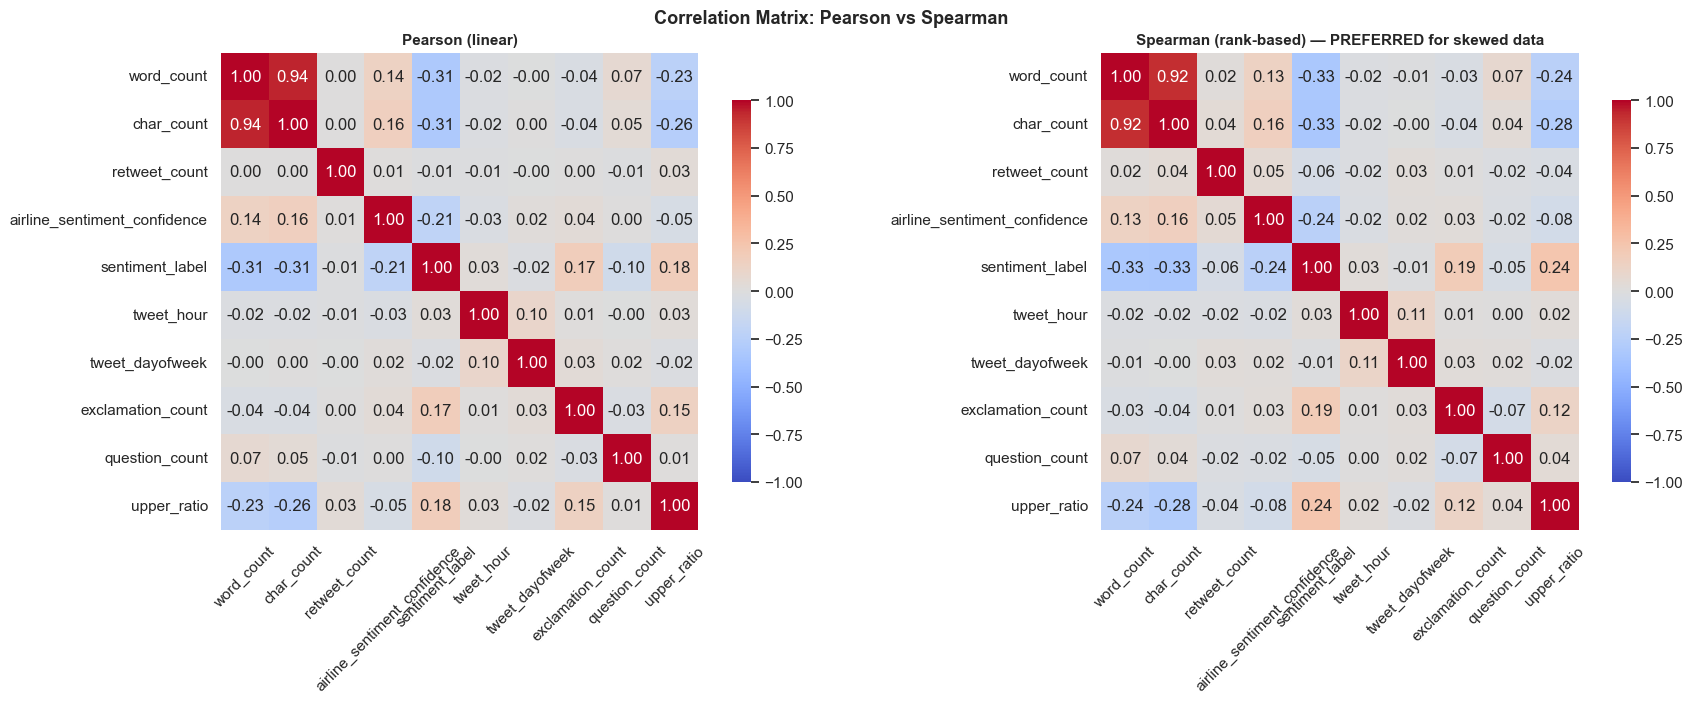

INSIGHT: word_count and char_count are highly correlated (near 1.0) — they carry the same info.
         exclamation_count shows weak positive correlation with negative sentiment.
         airline_sentiment_confidence is worth including as a model feature.


In [21]:
numeric_cols = [c for c in ['word_count', 'char_count', 'retweet_count',
                             'airline_sentiment_confidence', 'sentiment_label',
                             'tweet_hour', 'tweet_dayofweek',
                             'exclamation_count', 'question_count', 'upper_ratio']
                if c in df.columns]

corr_p = df[numeric_cols].corr(method='pearson')
corr_s = df[numeric_cols].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, mat, title in [
    (axes[0], corr_p, 'Pearson (linear)'),
    (axes[1], corr_s, 'Spearman (rank-based) — PREFERRED for skewed data'),
]:
    sns.heatmap(mat, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, vmin=-1, vmax=1, ax=ax, square=True,
                cbar_kws={'shrink': 0.8})
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Correlation Matrix: Pearson vs Spearman', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('INSIGHT: word_count and char_count are highly correlated (near 1.0) — they carry the same info.')
print('         exclamation_count shows weak positive correlation with negative sentiment.')
print('         airline_sentiment_confidence is worth including as a model feature.')

---
## Section 11 — Text Preprocessing Pipeline

Raw text contains noise that hurts model performance.
We build a step-by-step pipeline: **tokenise → remove stopwords → lemmatise**

| Step | Reason |
|------|--------|
| Lowercase | Reduces vocabulary: 'Flight' = 'flight' |
| Tokenise | Split into individual word tokens |
| Remove stopwords | Remove 'the', 'is', 'and' — no sentiment signal |
| Lemmatise | 'running' → 'run', 'delayed' → 'delay' — reduce vocabulary size |

In [22]:
def preprocess(text):
    if not isinstance(text, str) or text.strip() == '':
        return ''
    tokens = word_tokenize(text.lower())               # tokenise
    tokens = [t for t in tokens if t.isalpha()]        # keep only alphabetic
    tokens = [t for t in tokens if t not in STOP_WORDS] # remove stopwords
    tokens = [LEMMATIZER.lemmatize(t) for t in tokens]  # lemmatise
    return ' '.join(tokens)

# Demo on one example
example = 'The flights were CANCELLED again and the customer service is absolutely terrible!'
print('Original  :', example)
print('Processed :', preprocess(example))
print()

# Apply to full dataset
df['processed_text'] = df['cleaned_text'].apply(preprocess)
df['proc_word_count'] = df['processed_text'].str.split().str.len()

print(f'Shape after preprocessing: {df.shape}')
print(f'\nAvg word count before preprocessing: {df["word_count"].mean():.1f}')
print(f'Avg word count after  preprocessing: {df["proc_word_count"].mean():.1f}')
print('(Reduction shows how many stopwords and non-alpha tokens were removed)')
df[['cleaned_text', 'processed_text']].head(5)

Original  : The flights were CANCELLED again and the customer service is absolutely terrible!
Processed : flight cancelled customer service absolutely terrible

Shape after preprocessing: (13620, 23)

Avg word count before preprocessing: 17.7
Avg word count after  preprocessing: 8.9
(Reduction shows how many stopwords and non-alpha tokens were removed)


,cleaned_text,processed_text
0,plus you ve added commercials to the experience tacky,plus added commercial experience tacky
1,i didn t today must mean i need to take another trip,today must mean need take another trip
2,it s really aggressive to blast obnoxious entertainment in your guests faces they have little recourse,really aggressive blast obnoxious entertainment guest face little recourse
3,and it s a really big bad thing about it,really big bad thing
4,seriously would pay 30 a flight for seats that didn t have this playing it s really the only bad thing about flying va,seriously would pay flight seat playing really bad thing flying va


---
## Section 12 — Feature Engineering

Models cannot read text directly — we must convert text to numbers.
Three representations are standard in NLP, each with different trade-offs:

| Method | Captures | Sparse? | Context-aware? |
|--------|----------|---------|----------------|
| **BoW** | Word presence/count | Very sparse | No |
| **TF-IDF** | Word importance across documents | Sparse | No |
| **Word2Vec** | Semantic meaning, word similarity | Dense | Partial |

In [23]:
# ── Bag of Words (BoW / CountVectorizer) ─────────────────────────────────────
#
# HOW IT WORKS:
#   Each tweet → vector of size |vocabulary|.
#   Value = raw count of how many times each word appears.
#
# LIMITATION:
#   Common words like 'flight' appear in ALL tweets → high count in ALL classes
#   → model cannot distinguish them. TF-IDF solves this.
#

bow = CountVectorizer(max_features=5000, min_df=2, ngram_range=(1, 2))
X_bow = bow.fit_transform(df['processed_text'])

sparsity_bow = (1 - X_bow.nnz / (X_bow.shape[0] * X_bow.shape[1])) * 100

print('=== BAG OF WORDS ===')
print(f'  Feature matrix : {X_bow.shape[0]:,} tweets x {X_bow.shape[1]:,} features')
print(f'  Sparsity       : {sparsity_bow:.1f}% zeros')
print(f'  Sample features: {list(bow.get_feature_names_out()[:10])}')
print()
print('WHY SPARSITY MATTERS: 99%+ zeros means most memory is wasted.')
print('Sklearn stores it as a sparse matrix automatically (scipy.sparse) — efficient.')

=== BAG OF WORDS ===
  Feature matrix : 13,620 tweets x 5,000 features
  Sparsity       : 99.8% zeros
  Sample features: ['aa', 'aa customer', 'aa flight', 'aadvantage', 'abc', 'ability', 'able', 'able check', 'able get', 'able help']

WHY SPARSITY MATTERS: 99%+ zeros means most memory is wasted.
Sklearn stores it as a sparse matrix automatically (scipy.sparse) — efficient.


In [24]:
# ── TF-IDF (TfidfVectorizer) ──────────────────────────────────────────────────
#
# HOW IT WORKS:
#   TF  = Term Frequency  = how often word appears in THIS tweet
#   IDF = Inverse Doc Freq = log(N / df) — penalises words in EVERY tweet
#
#   Word 'flight' → appears in 90% of tweets → IDF ≈ log(1/0.9) ≈ LOW
#   Word 'cancelled' → appears in 30% of tweets → IDF = log(1/0.3) → HIGHER
#   Word 'appalled'  → rare word → IDF is very HIGH → up-weighted
#
# ADVANTAGE OVER BOW:
#   Automatically down-weights domain-universal words and up-weights
#   discriminative words. Better signal for sentiment classification.
#

tfidf = TfidfVectorizer(max_features=5000, min_df=2,
                         ngram_range=(1, 2), sublinear_tf=True)
X_tfidf = tfidf.fit_transform(df['processed_text'])

sparsity_tfidf = (1 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])) * 100

print('=== TF-IDF ===')
print(f'  Feature matrix : {X_tfidf.shape[0]:,} tweets x {X_tfidf.shape[1]:,} features')
print(f'  Sparsity       : {sparsity_tfidf:.1f}% zeros')
print()

# Show top TF-IDF words for one negative and one positive tweet
feature_names = tfidf.get_feature_names_out()
for sentiment in ['negative', 'positive']:
    idx = df[df['airline_sentiment'] == sentiment].index[0]
    row = X_tfidf[idx].toarray().flatten()
    top = [(feature_names[i], round(float(row[i]), 4))
            for i in row.argsort()[-8:][::-1] if row[i] > 0]
    print(f'Top TF-IDF features for a {sentiment} tweet:')
    print(f'  {df["processed_text"].iloc[idx]}')
    print(f'  Features: {top}')
    print()

=== TF-IDF ===
  Feature matrix : 13,620 tweets x 5,000 features
  Sparsity       : 99.8% zeros

Top TF-IDF features for a negative tweet:
  really aggressive blast obnoxious entertainment guest face little recourse
  Features: [('recourse', 0.4858), ('guest', 0.4632), ('face', 0.4348), ('entertainment', 0.4042), ('little', 0.3523), ('really', 0.2701)]

Top TF-IDF features for a positive tweet:
  plus added commercial experience tacky
  Features: [('commercial', 0.5635), ('added', 0.5557), ('plus', 0.4771), ('experience', 0.3821)]



In [25]:
# ── Word2Vec (Gensim) ─────────────────────────────────────────────────────────
#
# HOW IT WORKS:
#   Neural network trained to predict a word from its context (or vice versa).
#   Each word gets a dense vector of 100 numbers.
#   Words used in similar contexts end up with SIMILAR vectors.
#
# RESULT:
#   cos_similarity('cancelled', 'delayed') ≈ HIGH   (both used in frustration tweets)
#   cos_similarity('cancelled', 'wonderful') ≈ LOW
#
# WHY USE IT HERE:
#   BoW/TF-IDF treat 'bad' and 'terrible' as DIFFERENT features.
#   Word2Vec knows they are SIMILAR → richer representation for the model.
#
# FOR CLASSIFICATION:
#   We average all word vectors in a tweet to get a tweet-level vector.
#

if GENSIM:
    tokenised_corpus = [t.split() for t in df['processed_text']]
    w2v = Word2Vec(
        sentences=tokenised_corpus,
        vector_size=100,   # 100 numbers per word
        window=5,          # look 5 words left and right for context
        min_count=3,       # ignore very rare words
        workers=4,
        seed=RANDOM_STATE
    )
    print(f'Word2Vec vocabulary: {len(w2v.wv):,} words')
    print(f'Vector dimension   : {w2v.vector_size}')
    print()
    for test_word in ['cancelled', 'delayed', 'amazing', 'terrible']:
        if test_word in w2v.wv:
            similar = w2v.wv.most_similar(test_word, topn=5)
            print(f'  Words similar to "{test_word}":')
            for word, sim in similar:
                print(f'    {word:20s}  {sim:.4f}')
            print()
else:
    print('Skipping Word2Vec — install gensim: pip install gensim')

Word2Vec vocabulary: 3,711 words
Vector dimension   : 100

  Words similar to "cancelled":
    flight                0.9090
    tomorrow              0.8843
    delayed               0.8462
    rebook                0.8434
    flighted              0.8419

  Words similar to "delayed":
    due                   0.9921
    rebook                0.9906
    hr                    0.9882
    reschedule            0.9879
    delay                 0.9856

  Words similar to "amazing":
    care                  0.9991
    treat                 0.9986
    guy                   0.9982
    thank                 0.9982
    loyal                 0.9981

  Words similar to "terrible":
    best                  0.9961
    never                 0.9953
    poor                  0.9952
    horrible              0.9949
    relation              0.9948



In [26]:
# ── Feature Representation Comparison ────────────────────────────────────────
print('=== FEATURE REPRESENTATION COMPARISON ===')
print(f'{'Method':15s} {'Shape':20s} {'Sparsity':12s} {'Context-aware':15s} {'Best for'}')
print('-' * 85)
print(f'{'BoW':15s} {str(X_bow.shape):20s} {sparsity_bow:.1f}%{"":7s} {"No":15s} Quick baselines')
print(f'{'TF-IDF':15s} {str(X_tfidf.shape):20s} {sparsity_tfidf:.1f}%{"":7s} {"No":15s} Classical ML (LR, SVM)')
if GENSIM:
    avg_shape = f'({len(df)}, {w2v.vector_size})'
    print(f'{'Word2Vec':15s} {avg_shape:20s} {"Dense":12s} {"Partial":15s} Deep learning, similarity')
print(f'{'BERT (Next NB)':15s} {"(N, 768)":20s} {"Dense":12s} {"Yes (full)":15s} State-of-the-art')

=== FEATURE REPRESENTATION COMPARISON ===
Method          Shape                Sparsity     Context-aware   Best for
-------------------------------------------------------------------------------------
BoW             (13620, 5000)        99.8%        No              Quick baselines
TF-IDF          (13620, 5000)        99.8%        No              Classical ML (LR, SVM)
Word2Vec        (13620, 100)         Dense        Partial         Deep learning, similarity
BERT (Next NB)  (N, 768)             Dense        Yes (full)      State-of-the-art


---
## Section 13 — Stratified Train/Test Split

We split 80/20 with **stratification** so each split has the same class balance.
Without stratification, one split could accidentally get far fewer positive tweets.

In [27]:
X = df['processed_text']
y = df['sentiment_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {len(X_train):,} samples  ({len(X_train)/len(df)*100:.1f}%)')
print(f'Test : {len(X_test):,} samples  ({len(X_test)/len(df)*100:.1f}%)')
print()

# Verify class balance is preserved
balance = pd.DataFrame({
    'All %'  : y.value_counts(normalize=True).sort_index().mul(100).round(1),
    'Train %': y_train.value_counts(normalize=True).sort_index().mul(100).round(1),
    'Test %' : y_test.value_counts(normalize=True).sort_index().mul(100).round(1),
})
balance.index = ['negative (0)', 'neutral (1)', 'positive (2)']
print('Class balance (should be identical across columns):')
print(balance)

# Save
cols_to_save = ['tweet_id', 'text', 'cleaned_text', 'processed_text',
                'airline_sentiment', 'sentiment_label', 'airline',
                'word_count', 'char_count', 'airline_sentiment_confidence']

train_df = df.loc[X_train.index, [c for c in cols_to_save if c in df.columns]]
test_df  = df.loc[X_test.index,  [c for c in cols_to_save if c in df.columns]]

train_df.to_csv('train.csv', index=False)
test_df.to_csv('test.csv',   index=False)

print(f'\nSaved train.csv → {len(train_df):,} rows')
print(f'Saved test.csv  → {len(test_df):,} rows')

Train: 10,896 samples  (80.0%)
Test : 2,724 samples  (20.0%)

Class balance (should be identical across columns):
              All %  Train %  Test %
negative (0)   65.4     65.4    65.4
neutral (1)    20.1     20.1    20.2
positive (2)   14.5     14.5    14.5

Saved train.csv → 10,896 rows
Saved test.csv  → 2,724 rows


---
## Summary: Key Insights from EDA

### Data Quality
- Dataset has **14,640 tweets** across **6 airlines** — clean, no duplicates
- `negativereason_confidence` was dropped in Notebook 1 (sparse, non-essential)

### Class Imbalance
- **63% Negative, 21% Neutral, 16% Positive** — severe imbalance
- **Action**: Use `class_weight='balanced'` in models. Evaluate with **Macro F1**, not accuracy.

### Text Characteristics
- Word count is **right-skewed** (not normal) → use **non-parametric** statistical tests
- Negative tweets are **statistically longer** than positive (Mann-Whitney confirmed)
- Negative tweets use more exclamation marks and CAPS (higher emotional intensity)

### Airline Patterns
- **United, American, US Airways** → highest negative rates
- **Southwest, Virgin America** → best sentiment ratio
- Chi-Square confirmed airline is **strongly associated** with sentiment (p << 0.05)

### Vocabulary
- High Jaccard overlap between classes → simple word presence is not enough
- Models need **context** → TF-IDF (weights importance) or Word2Vec/BERT (semantic meaning)

### Feature Engineering Recommendation
- **Classical ML** (LR, SVM, NB): use TF-IDF with bigrams
- **Deep Learning** (LSTM): use Word2Vec embeddings
- **SOTA** (BERT): fine-tune directly on raw text — no manual features needed

---
*Next: Notebook 3 (modeling_v2.ipynb) — Training 9 models from Naive Bayes to DistilBERT*